# 10 — Günlük Optimal Toprak Nemi Eğrisi

**Hedef:** Her bitki için sezon boyunca günlük optimal toprak nemi eğrisi çıkar.

Yüksek verimli sezonlarda (üst %25) her gün toprağın nemi ne kadardı?
Bu eğri karar motoruna şunu söyler:

```
Gün 45 | Buğday
  Hedef nem:     0.28 m³/m³
  Mevcut nem:    0.22 m³/m³
  Gerekli su:    4.200 litre
  Beklenen verim: 4.800 kg/ha  ← IoT modeli tahmini
  Sulamassan:    3.900 kg/ha
```

**Çıktı:** `data/processed/crop_daily_moisture_profile.json`

In [4]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from pathlib import Path
from scipy.ndimage import uniform_filter1d

from src.data.loader import RAW_PATH

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROCESSED = Path('../data/processed')
FIGS      = Path('../outputs/figures/eda')

print('Hazır.')

Hazır.


## 1. Evre bazında toprak nemi verisi

Her (bitki × lokasyon × yıl × senaryo) için DVS evresine göre ortalama toprak nemi.

In [5]:
# Her sezon için gün numarası + günlük ortalama toprak nemi + hasat verimi
# DuckDB ile 5GB üzerinde — RAM'e yüklemeden
df_daily = duckdb.query(f"""
    WITH season_start AS (
        SELECT
            crop_name, latitude, longitude, year, wav_scenario,
            MIN(DATETIME::TIMESTAMP)  AS start_ts,
            MAX(harvest_twso)         AS harvest_twso,
            MAX(sim_success)          AS sim_success
        FROM '{RAW_PATH}'
        GROUP BY crop_name, latitude, longitude, year, wav_scenario
    )
    SELECT
        r.crop_name,
        s.harvest_twso,
        s.sim_success,
        DATEDIFF('day', s.start_ts, r.DATETIME::TIMESTAMP) AS day_of_season,
        AVG(r.SOIL_MOISTURE_0_7) AS mean_sm
    FROM '{RAW_PATH}' r
    JOIN season_start s
      ON  r.crop_name    = s.crop_name
      AND r.latitude     = s.latitude
      AND r.longitude    = s.longitude
      AND r.year         = s.year
      AND r.wav_scenario = s.wav_scenario
    WHERE s.sim_success = 1
    GROUP BY r.crop_name, s.harvest_twso, s.sim_success,
             day_of_season
""").df()

print(f'Satır sayısı: {len(df_daily):,}')
print(f'Bitki sayısı: {df_daily["crop_name"].nunique()}')
df_daily.head(3)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Satır sayısı: 7,674,117
Bitki sayısı: 22


,crop_name,harvest_twso,sim_success,day_of_season,mean_sm
0,barley,351.654436,1,215,0.023000
1,barley,351.654436,1,294,0.360417
2,barley,351.654436,1,328,0.348167


## 2. Evre bazında optimum nem profili — bitki başına

In [6]:
profiles = {}

for crop, grp in df_daily.groupby('crop_name'):
    high_yield_threshold = grp['harvest_twso'].quantile(0.75)
    low_yield_threshold  = grp['harvest_twso'].quantile(0.25)

    high_yield  = grp[grp['harvest_twso'] >= high_yield_threshold]
    low_yield   = grp[grp['harvest_twso'] <= low_yield_threshold]
    all_seasons = grp

    daily_opt = high_yield.groupby('day_of_season')['mean_sm'].agg(
        optimal='median',
        low=lambda x: x.quantile(0.25),
        high=lambda x: x.quantile(0.75),
    )

    if len(daily_opt) < 10:
        continue

    max_day   = int(daily_opt.index.max())
    daily_opt = daily_opt.reindex(range(max_day + 1)).interpolate('linear')

    optimal_smooth = uniform_filter1d(daily_opt['optimal'].ffill().bfill(), size=7)
    low_smooth     = uniform_filter1d(daily_opt['low'].ffill().bfill(), size=7)
    high_smooth    = uniform_filter1d(daily_opt['high'].ffill().bfill(), size=7)

    critical_by_day = all_seasons.groupby('day_of_season')['mean_sm'].quantile(0.10)
    critical_by_day = critical_by_day.reindex(range(max_day + 1)).interpolate('linear')
    critical_smooth = uniform_filter1d(critical_by_day.ffill().bfill(), size=7)

    upper_by_day = all_seasons.groupby('day_of_season')['mean_sm'].quantile(0.90)
    upper_by_day = upper_by_day.reindex(range(max_day + 1)).interpolate('linear')
    upper_smooth = uniform_filter1d(upper_by_day.ffill().bfill(), size=7)

    # harvest_twso SQL'de season başına MAX alındı — unique değerler = season verim listesi
    season_yields = grp['harvest_twso'].drop_duplicates()
    yield_high_median = float(season_yields[season_yields >= high_yield_threshold].median())
    yield_low_median  = float(season_yields[season_yields <= low_yield_threshold].median())
    yield_all_median  = float(season_yields.median())

    profiles[crop] = {
        'max_day': max_day,
        'days': list(range(max_day + 1)),
        'optimal_sm':  [round(float(v), 4) for v in optimal_smooth],
        'low_sm':      [round(float(v), 4) for v in low_smooth],
        'high_sm':     [round(float(v), 4) for v in high_smooth],
        'critical_sm': [round(float(v), 4) for v in critical_smooth],
        'upper_sm':    [round(float(v), 4) for v in upper_smooth],
        'yield_optimal_kg_ha': round(yield_high_median, 1),
        'yield_drought_kg_ha': round(yield_low_median, 1),
        'yield_typical_kg_ha': round(yield_all_median, 1),
    }

print(f'{len(profiles)} bitki için günlük profil oluşturuldu.')
print()
print(f'{"Bitki":<15}  {"Gün":>4}  {"Optimal (kg/ha)":>15}  {"Kurak (kg/ha)":>14}  {"Fark":>8}')
print('-' * 65)
for crop, p in sorted(profiles.items()):
    diff = p['yield_optimal_kg_ha'] - p['yield_drought_kg_ha']
    print(f'{crop:<15}  {p["max_day"]:>4}  {p["yield_optimal_kg_ha"]:>15.1f}  {p["yield_drought_kg_ha"]:>14.1f}  {diff:>8.1f}')

22 bitki için günlük profil oluşturuldu.

Bitki             Gün  Optimal (kg/ha)   Kurak (kg/ha)      Fark
-----------------------------------------------------------------
barley            366           7162.8          1095.8    6067.0
cassava           366           2809.9             1.3    2808.6
chickpea          366            127.1             0.5     126.6
cotton            366           1064.2            22.4    1041.8
cowpea            366            697.0            37.6     659.4
fababean          366           7925.7           415.8    7509.9
groundnut         366            392.6             0.6     392.0
maize             366           3995.1            54.6    3940.5
millet            366           1237.6            65.3    1172.3
mungbean          366           1065.3            14.0    1051.3
pigeonpea         366           4164.0           164.4    3999.6
potato            366           4819.5           217.0    4602.5
rapeseed          366           2806.3         

## 3. Özet tablo

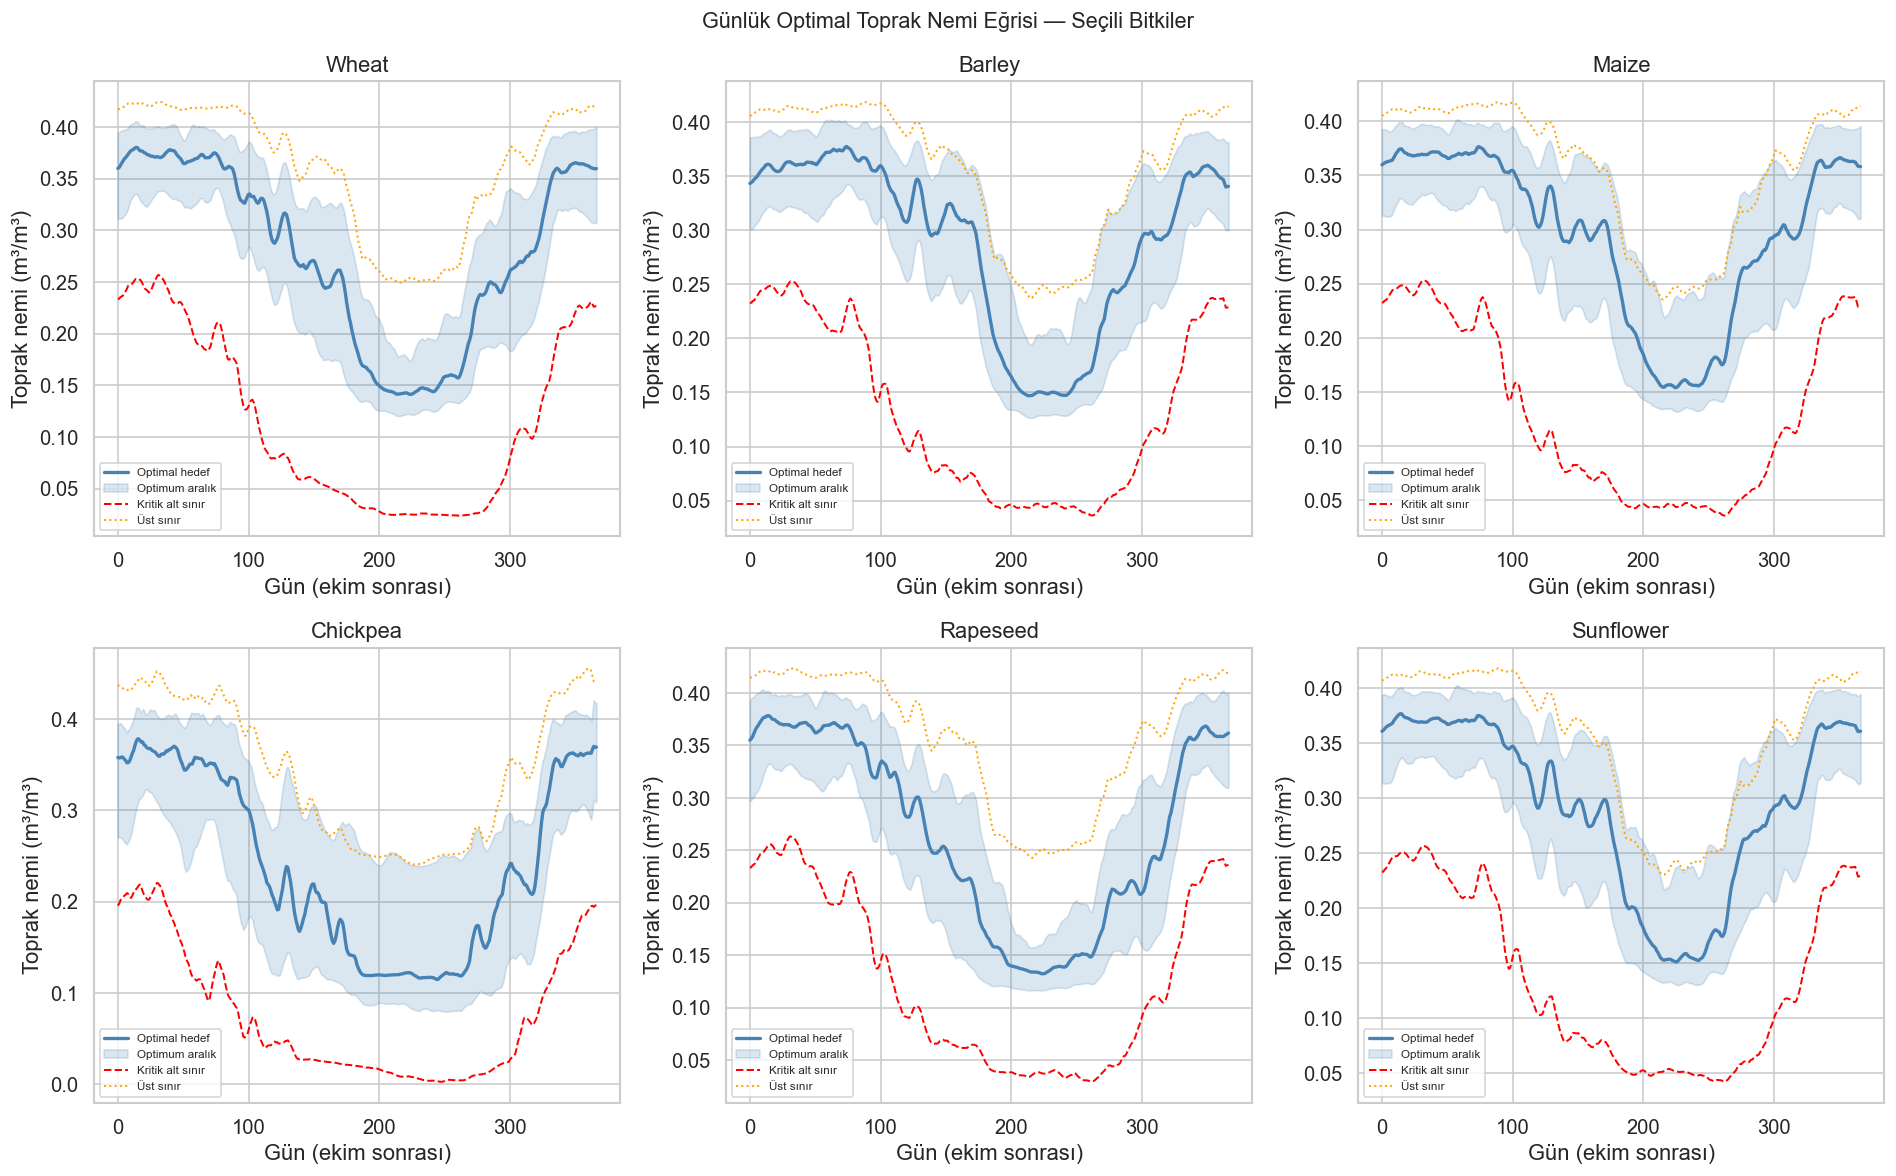

In [7]:
top_crops = [c for c in ['wheat', 'barley', 'maize', 'chickpea', 'rapeseed', 'sunflower'] if c in profiles]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, crop in zip(axes.flat, top_crops):
    p = profiles[crop]
    days       = p['days']
    optimal    = p['optimal_sm']
    low        = p['low_sm']
    high       = p['high_sm']
    critical   = p['critical_sm']
    upper      = p['upper_sm']

    ax.plot(days, optimal, color='steelblue', lw=2, label='Optimal hedef')
    ax.fill_between(days, low, high, alpha=0.2, color='steelblue', label='Optimum aralık')
    ax.plot(days, critical, color='red', lw=1.2, ls='--', label='Kritik alt sınır')
    ax.plot(days, upper,   color='orange', lw=1.2, ls=':', label='Üst sınır')

    ax.set_xlabel('Gün (ekim sonrası)')
    ax.set_ylabel('Toprak nemi (m³/m³)')
    ax.set_title(crop.capitalize())
    ax.legend(fontsize=7)

plt.suptitle('Günlük Optimal Toprak Nemi Eğrisi — Seçili Bitkiler', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / 'crop_daily_moisture_curve.png', bbox_inches='tight')
plt.show()

## 4. Görselleştirme — evre bazında optimum nem (seçili bitkiler)

In [8]:
out_path = PROCESSED / 'crop_daily_moisture_profile.json'
with open(out_path, 'w') as f:
    json.dump(profiles, f, indent=2, ensure_ascii=False)

print(f'Kaydedildi: {out_path}')
print(f'{len(profiles)} bitki, günlük çözünürlük')

Kaydedildi: ../data/processed/crop_daily_moisture_profile.json
22 bitki, günlük çözünürlük


## 5. Gün → Evre eşlemesi

IoT'de DVS yok. Karar motoru kaçıncı günde olduğunu bilerek evreyi tahmin edecek.

In [9]:
## Karar motoru bu profili nasıl kullanacak?

import json
import numpy as np

with open('../data/processed/crop_daily_moisture_profile.json') as f:
    profiles = json.load(f)

# Gün 45, buğday, 10 dönüm tarla
crop        = 'wheat'
season_day  = 45
current_sm  = 0.22       # IoT ölçümü (m³/m³)
field_area  = 10_000     # m²
soil_depth  = 0.07       # 7 cm sensör derinliği

p = profiles[crop]

# Günlük hedef nem değerleri
if season_day <= p['max_day']:
    target_sm   = p['optimal_sm'][season_day]
    low_sm      = p['low_sm'][season_day]
    critical_sm = p['critical_sm'][season_day]
    upper_sm    = p['upper_sm'][season_day]
else:
    target_sm = p['optimal_sm'][-1]   # son günün değeri

# Karar
if current_sm < critical_sm:
    alarm = 'KRİTİK — Acil sulama'
elif current_sm < low_sm:
    alarm = 'SULA'
elif current_sm > upper_sm:
    alarm = 'DURDUR — Aşırı nem'
else:
    alarm = 'NORMAL'

# Sulama miktarı
delta_sm = max(0, target_sm - current_sm)
litre    = delta_sm * field_area * soil_depth * 1000

print(f'Gün {season_day} | {crop}')
print(f'  Hedef nem:    {target_sm:.3f} m³/m³')
print(f'  Mevcut nem:   {current_sm:.3f} m³/m³')
print(f'  Durum:        {alarm}')
print(f'  Gerekli su:   {litre:,.0f} litre')

Gün 45 | wheat
  Hedef nem:    0.373 m³/m³
  Mevcut nem:   0.220 m³/m³
  Durum:        KRİTİK — Acil sulama
  Gerekli su:   107,380 litre


## 6. Kaydet

In [10]:
out_path = PROCESSED / 'crop_soil_moisture_profile.json'
with open(out_path, 'w') as f:
    json.dump(profiles, f, indent=2, ensure_ascii=False)

print(f'Kaydedildi: {out_path}')
print(f'{len(profiles)} bitki × 4 evre = {len(profiles)*4} hedef değer')

Kaydedildi: ../data/processed/crop_soil_moisture_profile.json
22 bitki × 4 evre = 88 hedef değer


## 7. Karar motoru bu profili nasıl kullanacak?

```python
crop        = 'wheat'
season_day  = 45
current_sm  = 0.17        # IoT ölçümü (m³/m³)
field_area  = 10_000      # m²
soil_depth  = 0.07        # 7 cm

profile = crop_profiles[crop]

# Hangi evredeyiz?
current_stage = next(
    (sk for sk, v in profile.items()
     if v['day_start'] <= season_day < v['day_end']),
    'stage_4'
)
stage = profile[current_stage]

target_sm   = stage['optimal_sm_target']
critical_sm = stage['critical_threshold']
is_waterlog = stage['waterlog_sensitive']

if is_waterlog:
    # Aşırı nem tehlikeli (nohut, tütün vb.)
    if current_sm > critical_sm:
        alarm = 'KRİTİK — Fazla su, drenaj gerekli'
    elif current_sm > stage['optimal_sm_high']:
        alarm = 'UYARI — Sulamayı durdur'
    elif current_sm < stage['optimal_sm_low']:
        alarm = 'SULA — Optimum altında'
        litre = (target_sm - current_sm) * field_area * soil_depth * 1000
    else:
        alarm = 'NORMAL'
else:
    # Kuraklık tehlikeli (çoğu bitki)
    if current_sm < critical_sm:
        alarm = 'KRİTİK — Acil sulama'
    elif current_sm < stage['optimal_sm_low']:
        alarm = 'SULA'
        litre = (target_sm - current_sm) * field_area * soil_depth * 1000
    else:
        alarm = 'NORMAL'
```